In [2]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
#from Utils import weighted_annual_resample
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

# inputs
path_archive = '/gws/nopw/j04/cpom/aduffey/pp_archive_hills/'
UKESM_ARISE_run_IDs = ['cl322', 'cl458', 'cl459', 'cl460', 'cl461']
UKESM_ARISE_run_dict = {'cl322':'r1i1p1f2', 'cl458':'r2i1p1f2', 'cl459':'r3i1p1f2',
                        'cl460':'r4i1p1f2', 'cl461':'r8i1p1f2'}
ens_mems_arise_UK = ['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r8i1p1f2']
CESM_ARISE_run_IDs = ['001', '002', '003', '004', '005'] # note there ten members, but we use only 5 here to align UKESM
ens_mems_CE = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1']
UKESM_arise_inj_logs_path = '../../Extra_data/ARISE_injection_stats/UKESM_feedback_stats/'
CESM_arise_inj_logs_path = '../../Extra_data/ARISE_injection_stats/CESM_feedback_stats/'
HiLLA_inj_mag = 12 # Tg per year total (6Tg per hemisphere)

In [3]:
### Settings
colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',
           'HiLLA_13':'red',
           'HiLLA_15':'green'}

model_colors = {'UKESM':'salmon',
                'CESM':'lightskyblue',
                'E3SM':'seagreen'}

models = ['UKESM', 'CESM', 'E3SM']

HiLLA_altitudes = ['13km', '15km']

assessment_period = [2050, 2069]

lat_band_dict = {'Tropics':[-23, 23], 
                 'Arctic':[66, 91],
                 'Antarctic':[-91, -66],
                 'Global':[-91, 91]}

In [4]:
def get_ds(run, var, table, zonal_mean=False):
    file = '/gws/nopw/j04/cpom/aduffey/pp_archive_hills/{r}/{t}/{v}/{r}_{v}.nc'.format(r=run, t=table, v=var)
    ds = xr.open_dataset(file)
    if zonal_mean:
        ds = ds.mean(dim='longitude')
    return ds

def cut_incomplete_years(ds):
    final_year = np.max(ds.time.dt.year.values)
    ds_final_year = ds.sel(time=str(final_year))
    if not len(ds_final_year.time.dt.month.values) == 12:
        ds = ds.sel(time=slice(None, str(final_year-1)))
    return ds

def spatial_mean(ds, region, zonal_mean=False):
    ds_ts = ds.sel(latitude=slice(lat_band_dict[region][0], lat_band_dict[region][1])).tas
    if not zonal_mean:
        ds_ts = ds_ts.mean(dim=['longitude'])
    weights = np.cos(np.deg2rad(ds_ts['latitude']))
    ds_ts_w = ds_ts.weighted(weights)
    ds_ts = ds_ts_w.mean(dim='latitude')
    return ds_ts.to_dataset(name='tas')


def set_time_to_center_of_bounds(ds, time_bounds_name='time_bounds'):
    time_bounds = ds[time_bounds_name]
    time_midpoints = time_bounds.mean(dim=time_bounds.dims[-1])
    new_ds = ds.assign_coords(time=time_midpoints)
    return new_ds

In [5]:
## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
ds_HiLLA_13_UK = get_ds(run = 'u-dm204dn587', var='tas', table='Amon').sel(time=slice(None, '2069'))
ds_HiLLA_15_UK = get_ds(run = 'u-dn760', var='tas', table='Amon').sel(time=slice(None, '2069'))

## repeat for CESM
ds_HiLLA_13_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case01_60NS_13km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).load()
ds_HiLLA_15_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case04_60NS_15km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).load()

## and E3SM
ds_HiLLA_13_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))


## get ssp245
def get_ssp245_ds(model, centre, variable, members, table='Amon', grid='gn'):
    ds_list = []
    for es in members:
        path = '/badc/cmip6/data/CMIP6/ScenarioMIP/{c}/{m}/ssp245/{e}/{t}/{v}/{g}/latest/'.format(
            c=centre, m=model, e=es, t=table,v=variable, g=grid)
        #files = os.listdir(path)
        ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).rename({'x':'longitude', 'y':'latitude'})
        ds_list.append(ds)
    
    DS = xr.concat(ds_list, dim='Ensemble_member')
    return DS
    
ds_ssp245_UK = get_ssp245_ds(model='UKESM1-0-LL', centre='MOHC', variable='tas', 
                                 members=ens_mems_arise_UK, table='Amon', grid='gn').mean('Ensemble_member').load()

ds_ssp245_CE = get_ssp245_ds(model='CESM2-WACCM', centre='NCAR', variable='tas', 
                             members=ens_mems_CE, table='Amon', grid='gn').mean('Ensemble_member').load()



## also get preindustrial, for comparison:
path = '/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/tas/gn/latest/'
ds_PI_UK = xr.open_mfdataset(path+'*.nc').rename({'lon':'longitude', 'lat':'latitude'})
ds_PI_UK = ds_PI_UK.mean('longitude').isel(time=slice(0, 600)).groupby("time.month").mean(dim="time").load()

path = '/badc/cmip6/data/CMIP6/CMIP/NCAR/CESM2-WACCM/piControl/r1i1p1f1/Amon/tas/gn/latest/'
ds_PI_CE = xr.open_mfdataset(path+'*.nc').rename({'lon':'longitude', 'lat':'latitude'})
ds_PI_CE = ds_PI_CE.mean('longitude').isel(time=slice(0, 600)).groupby("time.month").mean(dim="time").load()


### + ARISE
ds_list_tas = []
paths_tas = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/tas/gn/*/')

for path in paths_tas:
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).rename({'x':'longitude', 'y':'latitude'})
    ds_list_tas.append(ds)

ds_arise_UK = xr.concat(ds_list_tas, dim='Ensemble_member').mean('Ensemble_member')

## CE
ds_list_tas = []
path = '/gws/nopw/j04/cpom/aduffey/ARISE/CESM/arise/TREFHT/'
files = os.listdir(path)
files = [x for x in files if ".nc" in x]
# we keep only first 5 members to align with the ssp245 runs available
# this also means there are 5 members for both models, making figures easier to interpret
files = [x for x in files if int(x.split('.')[5]) < 6] 
for file in files:
    ds = rename_cmip6(xr.open_mfdataset(path+file)).rename({'x':'longitude', 'y':'latitude'})
    ds = set_time_to_center_of_bounds(ds)
    ds['Ensemble_member'] = file.split('.')[5]
    ds_list_tas.append(ds)
ds_arise_CE = xr.concat(ds_list_tas, dim='Ensemble_member')
#ds_arise_CE = set_time_to_center_of_bounds(ds_arise_CE) # needed as CESM direct output is weird, has time bounds correct, but time points themselves labelled by the end not start
ds_arise_CE = ds_arise_CE['TREFHT'].to_dataset(name='tas').mean('Ensemble_member')


## E3
ds_ssp245_E3 =  set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.control.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice('2015', '2069'))

In [6]:
### make monthly as 20-year mean
def process(ds, period_start='2051', period_end='2069'):
    ds = ds.mean('longitude')
    ds = ds.sel(time=slice(period_start, period_end))
    return ds.groupby("time.month").mean(dim="time")

ds_HiLLA_13_UK = process(ds_HiLLA_13_UK).load()
ds_HiLLA_15_UK = process(ds_HiLLA_15_UK).load()

ds_HiLLA_13_CE = process(ds_HiLLA_13_CE).load()
ds_HiLLA_15_CE = process(ds_HiLLA_15_CE).load()

ds_HiLLA_13_E3 = process(ds_HiLLA_13_E3).load()
ds_HiLLA_15_E3 = process(ds_HiLLA_15_E3).load()


ds_arise_UK = process(ds_arise_UK).load()
ds_arise_CE = process(ds_arise_CE).load()

ds_ssp245_UK = process(ds_ssp245_UK).load()
ds_ssp245_CE = process(ds_ssp245_CE).load()


ds_ssp245_early_E3 = process(ds_ssp245_E3, period_start='2035', period_end='2050').load() # also get early period for E3
ds_ssp245_E3 = process(ds_ssp245_E3).load()


In [7]:
#spatial_mean(data, 'Global', zonal_mean=True).mean('month').tas.item()

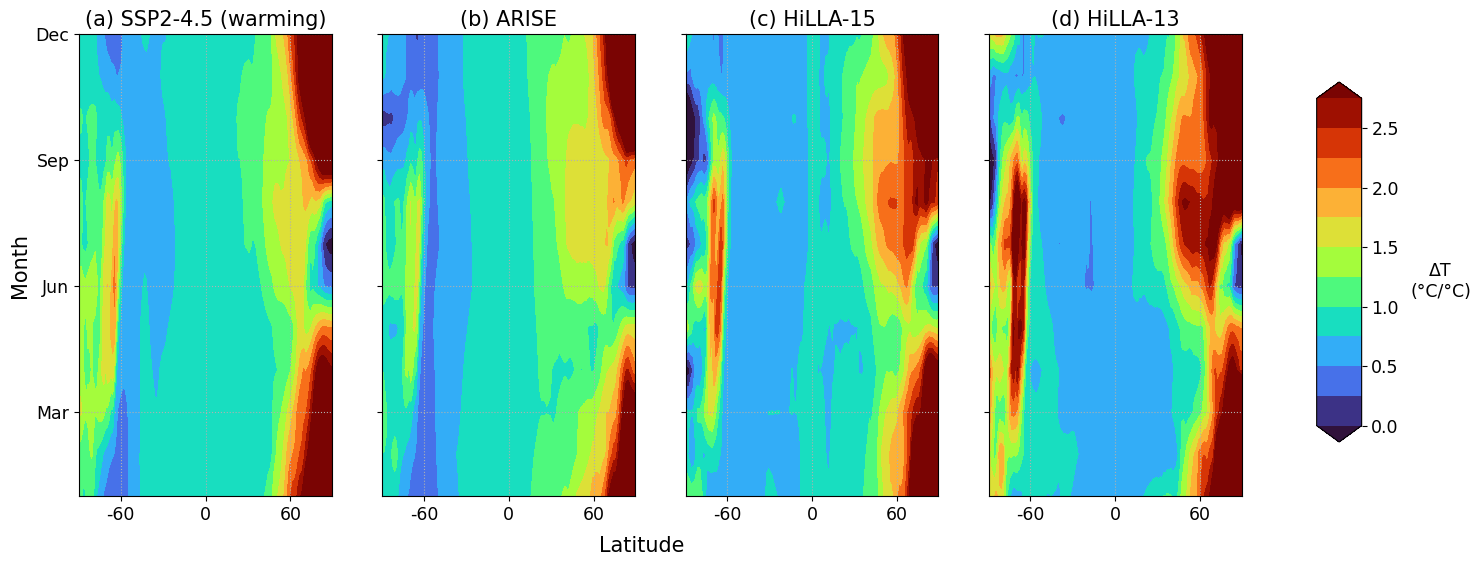

In [8]:
fig, axs = plt.subplots(1, 4, figsize=(15, 6), sharey=True)

data_UK = [(ds_ssp245_UK - ds_PI_UK),
           -(ds_arise_UK - ds_ssp245_UK), 
           -(ds_HiLLA_15_UK - ds_ssp245_UK),
           -(ds_HiLLA_13_UK - ds_ssp245_UK)]


data_CE = [(ds_ssp245_CE- ds_PI_CE),
           (ds_arise_CE - ds_ssp245_CE), 
           (ds_HiLLA_15_CE - ds_ssp245_CE),
           (ds_HiLLA_13_CE - ds_ssp245_CE)]

i=0
titles=['(a) SSP2-4.5 (warming)', '(b) ARISE', '(c) HiLLA-15', '(d) HiLLA-13']
#for run in ['u-de365', 'u-dg331']:
for data in data_UK:
    ax = axs[i]
    
    cs=ax.contourf(data.latitude.values, data.month.values, 
                   data.tas.values/spatial_mean(data, 'Global', zonal_mean=True).mean('month').tas.item(),
                   levels = np.arange(0, 3, 0.25),
                   #levels = [-8, -6, -4, -2, -1, -0.1, 0.1, 1, 2, 4, 6, 8],
                   #levels = [-7, -5, -3, -1, 1, 3, 5, 7],
                   #levels = [-7, -6, -5, -4, -3, -2, -1, -0.5, 0.5, 1, 2, 3, 4, 5, 6, 7],
                   cmap='turbo',
                   extend='both')
    ax.set_xticks([-60, 0, 60])
    ax.set_xticklabels(['-60', '0', '60'], fontsize='small')
    ax.set_yticks([3, 6, 9, 12])
    ax.set_yticklabels(['Mar', 'Jun', 'Sep', 'Dec'], fontsize='small')
    ax.grid(ls='dotted')
    ax.set_title(titles[i], fontsize='medium')
    i=i+1
    
axs[0].set_ylabel('Month')
fig.supxlabel('Latitude', fontsize='medium')
#plt.tight_layout()
#cbar_ax1 = fig.add_axes([0.05, -0.05, 0.35, 0.04])
cbar_ax1 = fig.add_axes([0.95, 0.2, 0.03, 0.6])
cbar1 = fig.colorbar(cs, cax=cbar_ax1, orientation='vertical') 
                     #label='\u0394 F_SW \n(W/m2)')
                     #ticks=[-8, -6, -4, -2, -1, -0.1, 0.1, 1, 2, 4, 6, 8])
cbar1.set_label('\u0394T\n(°C/°C)', rotation=0, ha='center', labelpad=30, fontsize='small')
cbar1.ax.tick_params(labelsize='small')

plt.savefig('Figures/zonal_seasonal_cooling.jpg', dpi=350, bbox_inches='tight')
plt.show()

# make into spatial means and plot in 1D:

In [9]:
def process(ds):
    ds = spatial_mean(ds, 'Arctic', zonal_mean=True)
    return ds

ds_HiLLA_13_UK = process(ds_HiLLA_13_UK).load()
ds_HiLLA_15_UK = process(ds_HiLLA_15_UK).load()
ds_HiLLA_13_CE = process(ds_HiLLA_13_CE).load()
ds_HiLLA_15_CE = process(ds_HiLLA_15_CE).load()
ds_HiLLA_13_E3 = process(ds_HiLLA_13_E3).load()
ds_HiLLA_15_E3 = process(ds_HiLLA_15_E3).load()

ds_arise_UK = process(ds_arise_UK).load()
ds_arise_CE = process(ds_arise_CE).load()

ds_ssp245_UK = process(ds_ssp245_UK).load()
ds_ssp245_CE = process(ds_ssp245_CE).load()

ds_ssp245_early_E3 = process(ds_ssp245_early_E3).load()
ds_ssp245_E3 = process(ds_ssp245_E3).load()

ds_PI_UK = process(ds_PI_UK).load()
ds_PI_CE = process(ds_PI_CE).load()

In [10]:
warming_UK = (ds_ssp245_UK - ds_PI_UK).tas
coolings_UK = {'HiLLA-13':(ds_HiLLA_13_UK - ds_ssp245_UK).tas,
               'HiLLA-15':(ds_HiLLA_15_UK - ds_ssp245_UK).tas,
                'ARISE':(ds_arise_UK - ds_ssp245_UK).tas}


warming_CE = (ds_ssp245_CE - ds_PI_CE).tas
coolings_CE = {'HiLLA-13':(ds_HiLLA_13_CE - ds_ssp245_CE).tas,
               'HiLLA-15':(ds_HiLLA_15_CE - ds_ssp245_CE).tas,
               'ARISE':(ds_arise_CE - ds_ssp245_CE).tas}

warming_E3 = (ds_ssp245_E3 - ds_ssp245_early_E3).tas
coolings_E3 = {'HiLLA-13':(ds_HiLLA_13_E3 - ds_ssp245_E3).tas,
               'HiLLA-15':(ds_HiLLA_15_E3 - ds_ssp245_E3).tas,
               }

warmings = {'UKESM':warming_UK, 'CESM':warming_CE, 'E3SM':warming_E3}
coolings = {'UKESM':coolings_UK, 'CESM':coolings_CE, 'E3SM':coolings_E3}

In [11]:
models

['UKESM', 'CESM', 'E3SM']

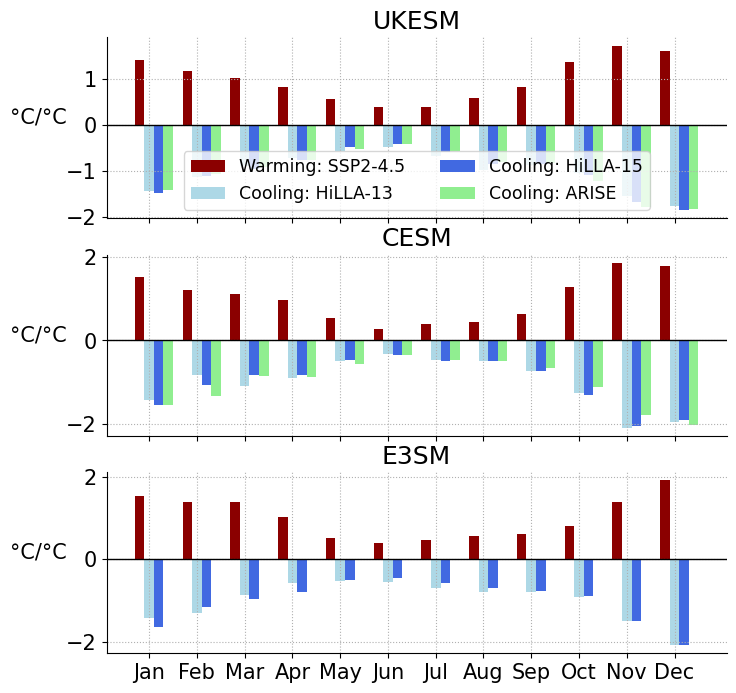

In [19]:
fig, axs = plt.subplots(3, 2, figsize=(8, 10), sharex=True)

months = np.arange(1, 13)
colors=['lightblue', 'royalblue', 'lightgreen']
width = 0.2

a=0

for model in models:
    ax = axs[a]
    warming_values = warmings[model].values
    cooling_values_raw = {k: v.values for k, v in coolings[model].items()}
    
    # Calculate annual means
    warming_mean = warming_values.mean()
    cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}
    
    # Normalize: divide each month by its series mean
    warming_norm = warming_values / warming_mean
    cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
                                                                  zip(cooling_values_raw.values(), cooling_means.values()))}
    
    
    # Plot warming bars (shifted left)
    ax.bar(months - width, warming_norm, width=width, label='Warming: SSP2-4.5', color='darkred')
    
    # Plot cooling bars (shifted right)
    for i, (name, values) in enumerate(cooling_norm.items()):
        ax.bar(months + i * width, values, width=width, label=f'Cooling: {name}', color=colors[i])

    # Customize
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(months)
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.set_ylabel('°C/°C', rotation=0, labelpad=20)
    #ax.set_title('Monthly Warming and Cooling (Normalized per Annual Mean)')
    axs[0].legend(loc='lower center', ncols=2, fontsize='small')
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(model)
    a=a+1
    
plt.savefig('Figures/cooling_seasonality_all.jpg', dpi=300, bbox_inches='tight')

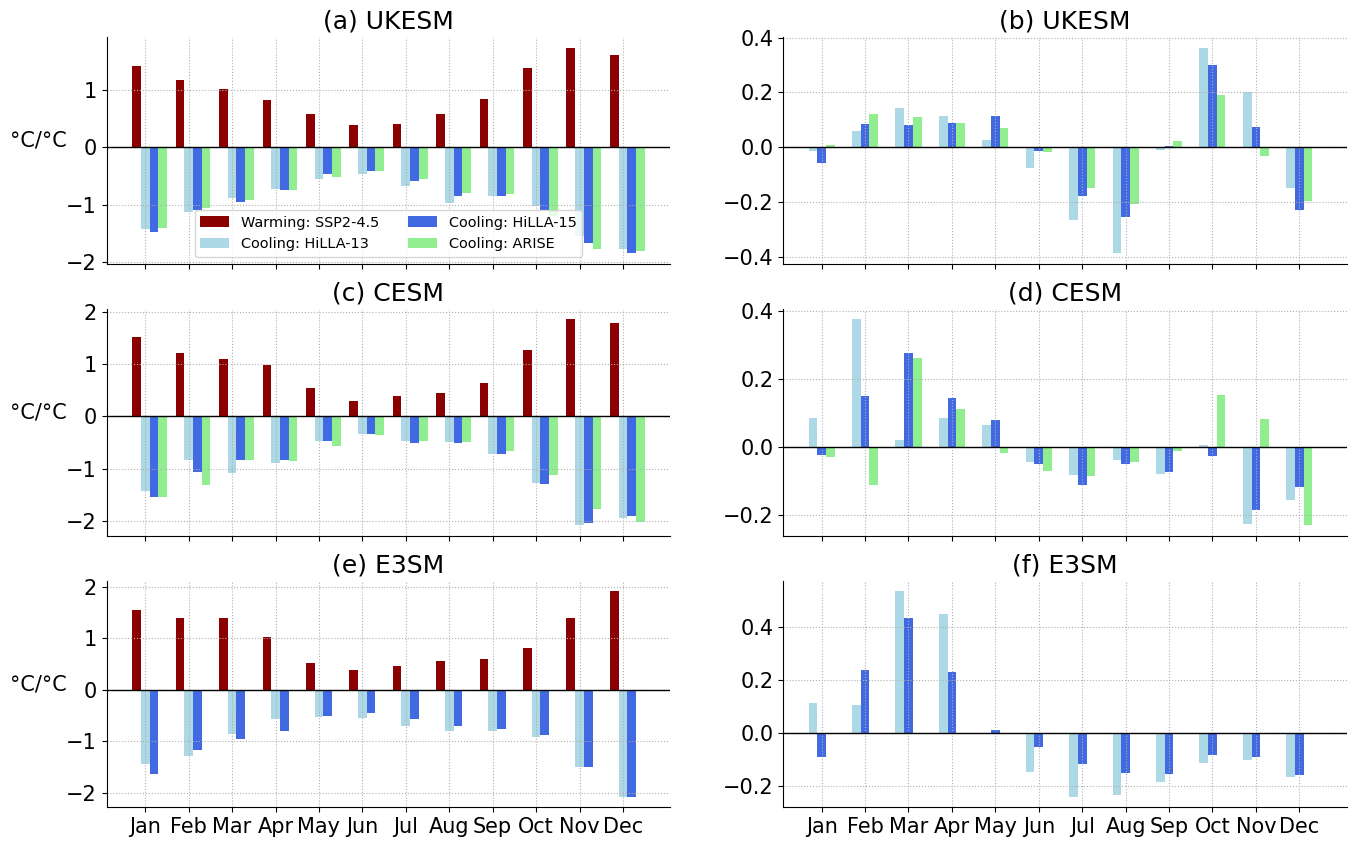

In [40]:
fig, axs = plt.subplots(3, 2, figsize=(16, 10), sharex=True)

months = np.arange(1, 13)
colors=['lightblue', 'royalblue', 'lightgreen']
width = 0.2
labs = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
a=0

for model in models:
    ax = axs[a, 0]
    warming_values = warmings[model].values
    cooling_values_raw = {k: v.values for k, v in coolings[model].items()}
    
    # Calculate annual means
    warming_mean = warming_values.mean()
    cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}
    
    # Normalize: divide each month by its series mean
    warming_norm = warming_values / warming_mean
    cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
                                                                  zip(cooling_values_raw.values(), cooling_means.values()))}
    
    # Plot warming bars (shifted left)
    ax.bar(months - width, warming_norm, width=width, label='Warming: SSP2-4.5', color='darkred')
    
    # Plot cooling bars (shifted right)
    for i, (name, values) in enumerate(cooling_norm.items()):
        ax.bar(months + i * width, values, width=width, label=f'Cooling: {name}', color=colors[i])
    ax.set_title(model)
    ax.set_ylabel('°C/°C', rotation=0, labelpad=20)
    ax.set_title(str(labs[2*a] + ' ' + model))
    a=a+1

a=0
for model in models:
    ax = axs[a, 1]
    warming_values = warmings[model].values
    cooling_values_raw = {k: v.values for k, v in coolings[model].items()}
    
    # Calculate annual means
    warming_mean = warming_values.mean()
    cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}
    
    # Normalize: divide each month by its series mean
    warming_norm = warming_values / warming_mean
    cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
                                                                  zip(cooling_values_raw.values(), cooling_means.values()))}
    
    for i, (name, values) in enumerate(cooling_norm.items()):
        ax.bar(months + (i-1)*width, values + warming_norm, width=width, label=f'Cooling: {name}', color=colors[i])
    ax.set_title(str(labs[2*a+1] + ' ' + model))
    a=a+1

axs.flatten()[0].legend(loc='lower center', ncols=2, fontsize='x-small')
for ax in axs.flatten():
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(months)
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    #ax.set_title('Monthly Warming and Cooling (Normalized per Annual Mean)')
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    
    
plt.savefig('Figures/cooling_seasonality_all.jpg', dpi=300, bbox_inches='tight')

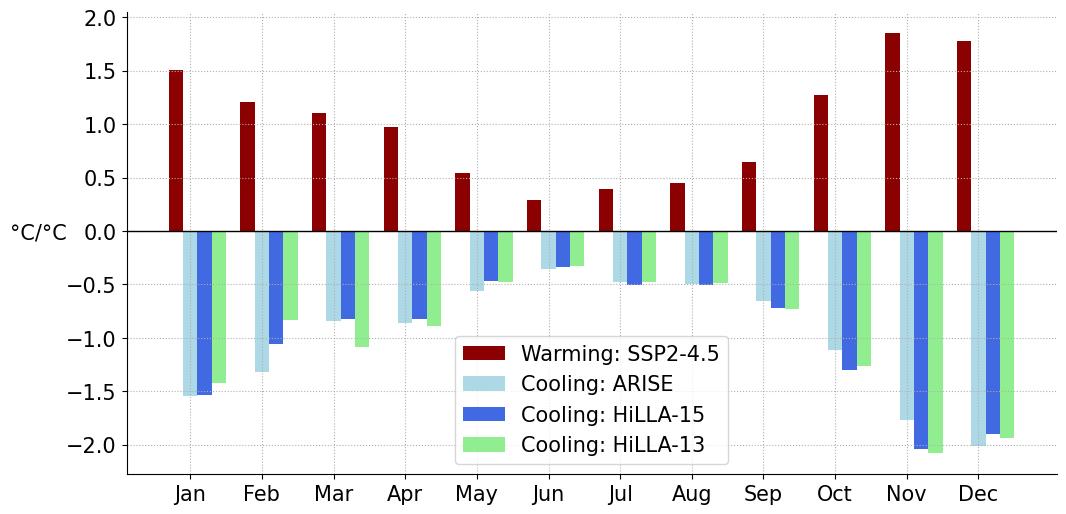

In [181]:

months = np.arange(1, 13)
# Extract raw values
warming_values = warming_CE.values
cooling_values_raw = {k: v.values for k, v in coolings_CE.items()}

# Calculate annual means
warming_mean = warming_values.mean()
cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}

# Normalize: divide each month by its series mean
warming_norm = warming_values / warming_mean
cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
                        zip(cooling_values_raw.values(), cooling_means.values()))}

# Set bar width
width = 0.2

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot warming bars (shifted left)
ax.bar(months - width, warming_norm, width=width, label='Warming: SSP2-4.5', color='darkred')

# Plot cooling bars (shifted right)
for i, (name, values) in enumerate(cooling_norm.items()):
    ax.bar(months + i * width, values, width=width, label=f'Cooling: {name}', color=colors[i])

# Customize
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_ylabel('°C/°C', rotation=0, labelpad=20)
#ax.set_title('Monthly Warming and Cooling (Normalized per Annual Mean)')
ax.legend()
ax.grid(ls='dotted')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.savefig('Figures/cooling_seasonality_CE_v1.jpg', dpi=300, bbox_inches='tight')

IndexError: list index out of range

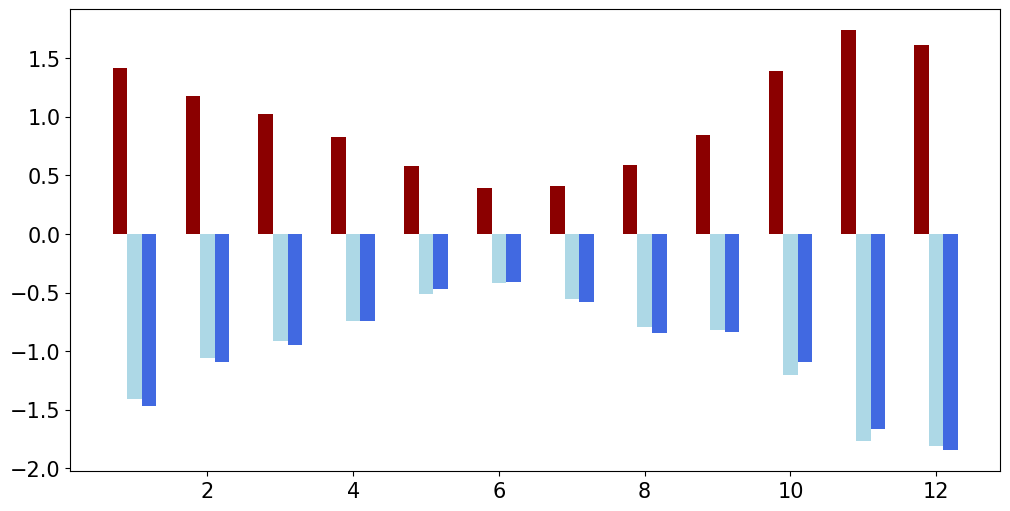

In [19]:
HiLLA_13_forcing_arctic = [-9.15263807e-04, -1.49785181e-03, -1.48498099e-01, -1.28666922e+00, -3.87595397e+00, -8.82804103e+00, -1.21534585e+01, -7.05675573e+00, -1.64637909e+00, -1.63018235e-01, -8.68931410e-03, -6.68696344e-05]

months = np.arange(1, 13)
colors=['lightblue', 'royalblue']
# Extract raw values
warming_values = warming_UK.values
cooling_values_raw = {k: v.values for k, v in coolings_UK.items()}

# Calculate annual means
warming_mean = warming_values.mean()
cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}

# Normalize: divide each month by its series mean
warming_norm = warming_values / warming_mean
cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
                                                              zip(cooling_values_raw.values(), cooling_means.values()))}

# Set bar width
width = 0.2

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot warming bars (shifted left)
ax.bar(months - width, warming_norm, width=width, label='Warming: SSP2-4.5', color='darkred')

# Plot cooling bars (shifted right)
for i, (name, values) in enumerate(cooling_norm.items()):
    ax.bar(months + i * width, values, width=width, label=f'Cooling: {name}', color=colors[i])

# Customize
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_ylabel('°C/°C', rotation=0, labelpad=20)
#ax.set_title('Monthly Warming and Cooling (Normalized per Annual Mean)')
ax.legend(loc='upper center')
ax.grid(ls='dotted')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-1.9, 1.9)

# === Add secondary axis ===
ax2 = ax.twinx()
ax2.plot(months, HiLLA_13_forcing_arctic, color='royalblue', marker='o', linestyle='-', label='Forcing: HiLLA-13')
ax2.set_ylabel('W/m²', rotation=0, labelpad=20)
ax2.spines['top'].set_visible(False)
ax2.set_ylim(-14, 14)
ax2.legend(loc='lower left')

plt.savefig('Figures/cooling_seasonality_UK_v2.jpg', dpi=300, bbox_inches='tight')

In [ ]:
# Setup months
months = np.arange(1, 13)

# === UKESM ===
warming_UK_values = warming_UK.values
coolings_UK_values = {k: v.values for k, v in coolings_UK.items()}

# Make coolings negative for plotting downward
coolings_UK_negative = {k: -vals for k, vals in coolings_UK_values.items()}

# === CESM ===
warming_CE_values = warming_CE.values
coolings_CE_values = {k: v.values for k, v in coolings_CE.items()}

coolings_CE_negative = {k: -vals for k, vals in coolings_CE_values.items()}

# === Plotting ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

region_data = [
    ('UK', warming_UK_values, coolings_UK_negative, axes[0]),
    ('CE', warming_CE_values, coolings_CE_negative, axes[1])
]

width = 0.2
colors = ['blue', 'green', 'purple']

for region_label, warming_vals, cooling_vals, ax in region_data:
    # Plot warming
    ax.bar(months - width, warming_vals, width=width, label='Warming', color='red')
    
    # Plot coolings
    for i, (name, values) in enumerate(cooling_vals.items()):
        ax.bar(months + i * width, values, width=width, label=f'Cooling: {name}', color=colors[i])
    
    # Customize
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(months)
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.set_title(f'{region_label} Region')
    ax.set_xlabel('Month')
    if ax == axes[0]:
        ax.set_ylabel('Temperature Change (°C)')

# Add shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4)

fig.suptitle('Monthly Warming and Cooling Patterns (Raw Values)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Setup months
months = np.arange(1, 13)

# === UK REGION ===
warming_UK_values = warming_UK.values
coolings_UK_values = {k: v.values for k, v in coolings_UK.items()}

warming_UK_mean = warming_UK_values.mean()
coolings_UK_means = {k: vals.mean() for k, vals in coolings_UK_values.items()}

warming_UK_norm = warming_UK_values / warming_UK_mean
coolings_UK_norm = {k: (-vals / mean) for k, (vals, mean) in zip(coolings_UK_values.keys(),
                                                            zip(coolings_UK_values.values(), coolings_UK_means.values()))}

# === CE REGION ===
warming_CE_values = warming_CE.values
coolings_CE_values = {k: v.values for k, v in coolings_CE.items()}

warming_CE_mean = warming_CE_values.mean()
coolings_CE_means = {k: vals.mean() for k, vals in coolings_CE_values.items()}

warming_CE_norm = warming_CE_values / warming_CE_mean
coolings_CE_norm = {k: (-vals / mean) for k, (vals, mean) in zip(coolings_CE_values.keys(),
                                                                  zip(coolings_CE_values.values(), coolings_CE_means.values()))}

# === Plotting ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

region_data = [
    ('UK', warming_UK_norm, coolings_UK_norm, axes[0]),
    ('CE', warming_CE_norm, coolings_CE_norm, axes[1])
]

width = 0.2
colors = ['blue', 'green', 'purple']

for region_label, warming_norm, cooling_norm, ax in region_data:
    # Plot warming
    ax.bar(months - width, warming_norm, width=width, label='Warming', color='red')
    
    # Plot coolings
    for i, (name, values) in enumerate(cooling_norm.items()):
        ax.bar(months + i * width, values, width=width, label=f'Cooling: {name}', color=colors[i])
    
    # Customize
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(months)
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.set_title(f'{region_label} Region')
    ax.set_xlabel('Month')
    if ax == axes[0]:
        ax.set_ylabel('Normalized Temperature Change (per °C annual mean)')

# Add shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4)

fig.suptitle('Monthly Warming and Cooling Patterns (Normalized per Annual Mean)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()


In [ ]:

months = np.arange(1, 13)

# Extract raw values
warming_values = warming.values
cooling_values_raw = {k: v.values for k, v in coolings.items()}

# Calculate annual means
warming_mean = warming_values.mean()
cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}

# Normalize: divide each month by its series mean
warming_norm = warming_values / warming_mean
cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
                                                              zip(cooling_values_raw.values(), cooling_means.values()))}

# Set bar width
width = 0.2

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot warming bars (shifted left)
ax.bar(months - width, warming_norm, width=width, label='Warming', color='red')

# Plot cooling bars (shifted right)
for i, (name, values) in enumerate(cooling_norm.items()):
    ax.bar(months + i * width, -values, width=width, label=f'Cooling: {name}')

# Customize
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_ylabel('Normalized Temperature Change (per °C annual mean)')
ax.set_title('Monthly Warming and Cooling (Normalized per Annual Mean)')
ax.legend()

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

months = np.arange(1, 13)

# Extract raw values
warming_values = warming.values
cooling_values_raw = {k: v.values for k, v in coolings.items()}

# Calculate annual means
warming_mean = warming_values.mean()
cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}

# Normalize: divide each month by its series mean
warming_norm = warming_values / warming_mean
cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
                                                              zip(cooling_values_raw.values(), cooling_means.values()))}

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot warming line
ax.plot(months, warming_norm, marker='o', color='red', label='Warming')

# Plot cooling lines
colors = ['blue', 'green', 'purple']
for color, (name, values) in zip(colors, cooling_norm.items()):
    ax.plot(months, -values, marker='o', color=color, label=f'Cooling: {name}')

# Customize
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(months)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_ylabel('Normalized Temperature Change (per °C annual mean)')
ax.set_title('Monthly Warming and Cooling Patterns (Normalized per Annual Mean)')
ax.legend()

plt.show()
